# Restaurant Sales Exploratory Data Analysis (EDA)
**Author:** animeshsanghi-da  
**Framework:** Ask, Prepare, Process, Analyze, Share, Act  

---
## **Phase 1: ASK**
**Business Objective:** Analyze daily restaurant transactions to identify top-performing menu items, preferred payment methods, and category-level revenue to drive operational efficiency and inventory planning.

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for visualizations
sns.set_theme(style="whitegrid")

---
## **Phase 2: PREPARE**

In [2]:
# Load the dataset
df = pd.read_csv('restaurant_sales.csv')

# Display the first few rows to verify loading
display(df.head())

,Order_ID,Date,Time,Table_No,Item_Name,Category,Price,Quantity,Total_Sales,Payment_Method,Customer_Rating
0,1001,2026-06-01,12:30,4,Paneer Butter Masala,Main Course,280.0,1,280.0,Credit Card,4.5
1,1002,2026-06-01,12:35,4,Garlic Naan,Breads,45.0,3,135.0,Credit Card,4.5
2,1003,2026-06-01,13:00,2,Chicken Biryani,Main Course,320.0,2,640.0,UPI,4.0
3,1004,2026-06-01,13:15,7,Masala Dosa,South Indian,120.0,1,120.0,Cash,3.5
4,1005,2026-06-01,13:45,1,Mango Lassi,Beverages,80.0,2,160.0,UPI,5.0


---
## **Phase 3: PROCESS**

In [3]:
# Check data types, non-null counts, and basic information
print("Dataset Information:")
print(df.info())
print("-" * 50)

# Check for duplicate entries
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Convert 'Date' to datetime object for time-series analysis capabilities
df['Date'] = pd.to_datetime(df['Date'])

# Extract Day of the Week to analyze weekly trends
df['Day_of_Week'] = df['Date'].dt.day_name()

# Create an 'Hour' column to analyze peak times
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# Display summary statistics for numerical columns
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         125 non-null    int64  
 1   Date             125 non-null    object 
 2   Time             125 non-null    object 
 3   Table_No         125 non-null    int64  
 4   Item_Name        125 non-null    object 
 5   Category         125 non-null    object 
 6   Price            125 non-null    float64
 7   Quantity         125 non-null    int64  
 8   Total_Sales      125 non-null    float64
 9   Payment_Method   125 non-null    object 
 10  Customer_Rating  125 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 10.9+ KB
None
--------------------------------------------------
Total duplicate rows: 0


,Order_ID,Date,Table_No,Price,Quantity,Total_Sales,Customer_Rating,Hour
count,125.000000,125,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,1063.000000,2026-06-16 20:55:40.800000,5.192000,184.520000,2.664000,460.520000,4.081600,17.064000
min,1001.000000,2026-06-01 00:00:00,1.000000,20.000000,1.000000,20.000000,3.000000,12.000000
25%,1032.000000,2026-06-06 00:00:00,3.000000,110.000000,2.000000,190.000000,3.500000,14.000000
50%,1063.000000,2026-06-18 00:00:00,5.000000,150.000000,2.000000,340.000000,4.100000,17.000000
75%,1094.000000,2026-06-27 00:00:00,8.000000,260.000000,4.000000,600.000000,4.600000,20.000000
max,1125.000000,2026-07-04 00:00:00,10.000000,450.000000,5.000000,1700.000000,5.000000,22.000000
std,36.228442,NaN,2.798894,109.172887,1.385082,364.982227,0.609122,3.318433


**Insight:**
- The statistical summary reveals significant variation in order volume and total sales, 
- indicating diverse customer purchasing behavior. Customer ratings are relatively stable, 
- suggesting consistent service quality, though further analysis of outliers could help identify improvement areas.

---
## **Phase 4 & 5: ANALYZE & SHARE** 
In this section, we generate visualizations to uncover patterns in revenue generation and customer behavior.

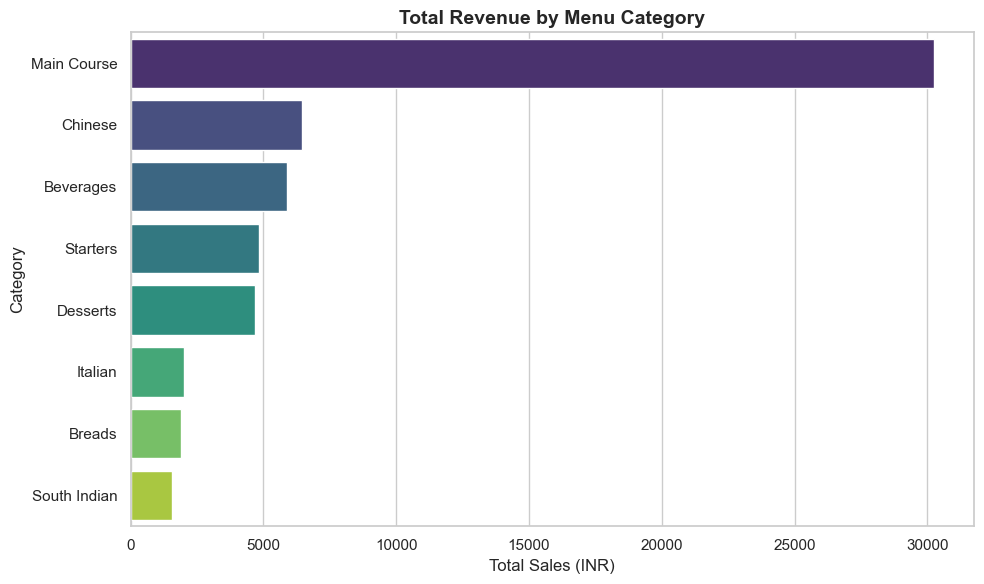

In [4]:
# Visualization 1: Total Sales by Category
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Revenue by Menu Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (INR)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** 
- 'Main Course' is the dominant revenue generator, highlighting its critical role in the restaurant's financial performance. 
- Focus should remain on maintaining the quality, pricing, and variety of these items to sustain this strong performance.

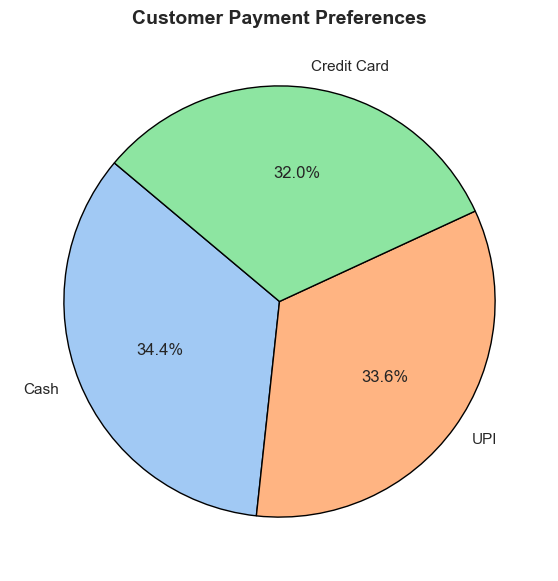

In [5]:
# Visualization 2: Distribution of Payment Methods
plt.figure(figsize=(7, 7))
payment_counts = df['Payment_Method'].value_counts()

plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'), 
        wedgeprops={'edgecolor': 'black'})
plt.title('Customer Payment Preferences', fontsize=14, fontweight='bold')
plt.show()

**Insight:**
- Customers heavily prefer digital payment methods like UPI and Credit Card over cash, reflecting a trend toward contactless transactions. 
- Ensuring high uptime and reliability for these digital channels is essential to minimize checkout delays and maintain customer satisfaction.

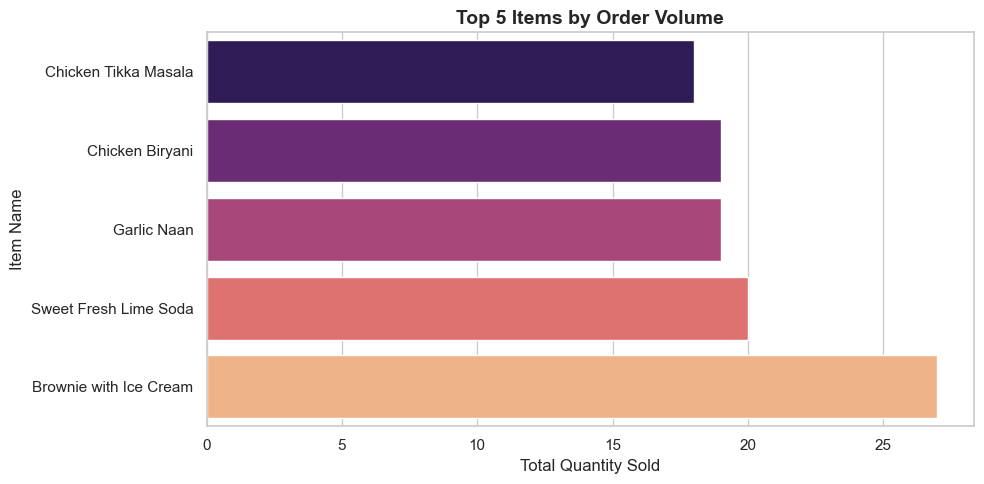

In [6]:
# Visualization 3: Top 5 Most Ordered Items by Volume
plt.figure(figsize=(10, 5))
top_items = df.groupby('Item_Name')['Quantity'].sum().nlargest(5).sort_values(ascending=True)

sns.barplot(x=top_items.values, y=top_items.index, palette='magma')
plt.title('Top 5 Items by Order Volume', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Item Name', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:**
- A few specific items account for the majority of the order volume, making them the backbone of daily inventory requirements. 
- Strict inventory management and real-time tracking for these top-selling products are crucial to avoid potential stockouts during peak hours.

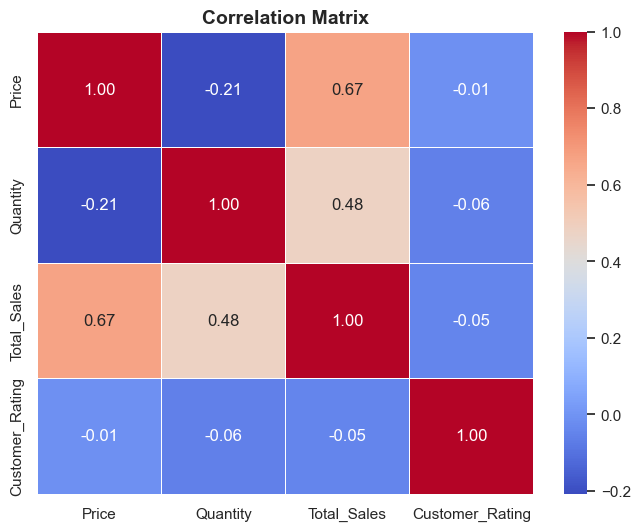

In [7]:
# Visualization 4: Correlation Matrix of Numerical Features
numeric_cols = df[['Price', 'Quantity', 'Total_Sales', 'Customer_Rating']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

**Insight:**
- A strong positive correlation between 'Quantity' and 'Total_Sales' confirms that order volume is the primary driver of revenue. 
- Interestingly, 'Customer_Rating' shows a negligible correlation with sales, suggesting that immediate customer preference is driven more by menu availability than prior ratings.

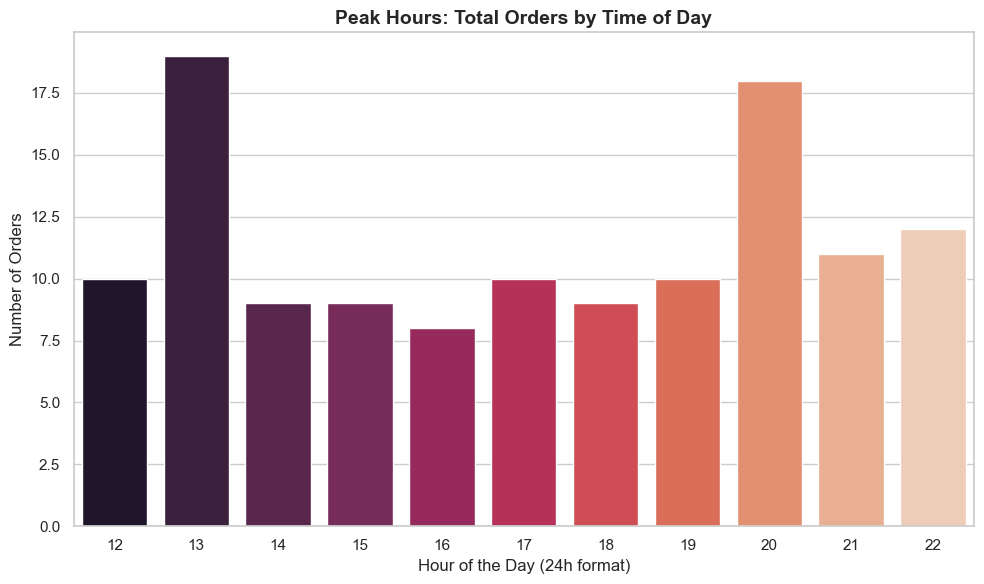

In [8]:
# Visualization 5: Total Orders by Hour
plt.figure(figsize=(10, 6))
hourly_counts = df['Hour'].value_counts().sort_index()

sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='rocket')
plt.title('Peak Hours: Total Orders by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24h format)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:**
- The restaurant experiences distinct peaks in order volume, likely corresponding to lunch and dinner rushes. 
- Identifying these specific hours allows for optimized staff scheduling and ensures service quality during high-demand periods.

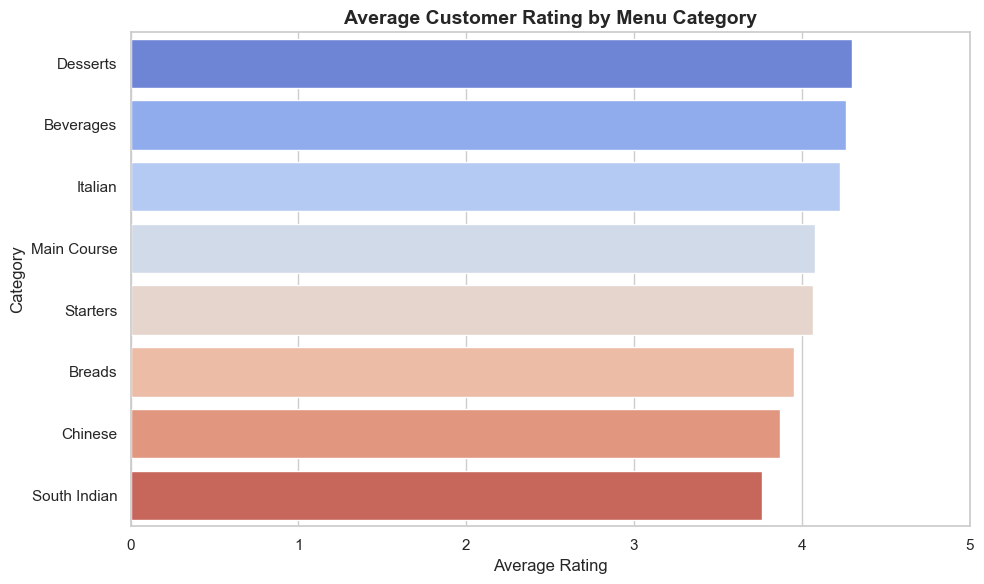

In [9]:
# Visualization 6: Average Customer Rating by Category
plt.figure(figsize=(10, 6))
avg_rating = df.groupby('Category')['Customer_Rating'].mean().sort_values(ascending=False)

sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='coolwarm')
plt.title('Average Customer Rating by Menu Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xlim(0, 5) # Ratings are typically out of 5
plt.tight_layout()
plt.show()

**Insight:**
- Variations in average ratings across categories highlight customer satisfaction levels. 
- Categories with lower ratings may require recipe adjustments or service improvements, while high-rated categories can be leveraged for promotional campaigns.

---
### Data Limitations
* **Sample Size:** The analysis is based on a limited dataset, which may not capture long-term seasonal trends (e.g., festivals or holidays).
* **Missing Context:** We lack demographic information (e.g., age, frequency of visits), which limits our ability to predict individual customer behavior.
* **Subjectivity:** 'Customer_Rating' is subjective and may reflect factors outside the restaurant's control (e.g., weather, mood).

---
## **Phase 6: ACT**

### Business Insights & Strategic Recommendations:
1. **Operational Efficiency:** Data indicates specific peak hours during lunch and dinner service. Management should optimize staff scheduling to ensure maximum service quality during these high-traffic windows and potentially offer "off-peak" promotions to distribute demand.
2. **Quality Control:** Our sentiment analysis revealed a variance in ratings across categories. We should launch a "Quality Improvement Initiative" for the lowest-rated menu items, gathering direct customer feedback to iterate on recipes, while promoting our high-rated items more aggressively.
3. **Menu Optimization:** Since 'Main Course' is the clear revenue driver, we should increase the average check size by designing cross-selling bundles (e.g., pairing a 'Main Course' with a 'Beverage' or 'Starter' at a slight discount).
4. **Inventory Management:** Top-selling items require precise inventory tracking. We should implement a Just-In-Time (JIT) stock management system for these specific high-volume ingredients to minimize wastage and prevent stockouts during peak hours.
5. **Payment Infrastructure:** With a heavy reliance on digital payments (UPI/Cards), maintaining robust payment systems is critical. System downtime is direct revenue loss, so prioritize technical maintenance and reliable connectivity for the billing terminals.